# A1 — Probe build on the base model (Qwen3.5-35B-A3B)

Registered design and gates: `notes/03_phaseA_registered_plan.md`. This notebook:
1. extracts last-token residual-stream activations at all 40 layers for the six TTPD topic sets (affirmative + negated), raw format;
2. runs leave-one-topic-out validation of the TTPD truth×polarity probe per layer, picks L*, checks gate **G1** (affirmative ≥ 85%, negated ≥ 80%);
3. fits the final probe at L* and saves it;
4. sanity-checks the six fabricated claims + subclaims (predictions A1-a/b/c);
5. runs the association-logprob readout under three prefixes (prediction A1-d).
Chat-format repeat of steps 1–2 is the last cell (secondary).

In [1]:
# --- setup (shared by all Phase A notebooks) ---
import sys, json, time, numpy as np, pandas as pd, torch
from pathlib import Path
NN = Path("/workspace/nn"); sys.path.insert(0, str(NN / "src"))
from nnprobe import model as M, acts as A, ttpd as T, data as D, logprob as LP
D.ROOT = NN                                   # data/ lives under /workspace/nn on the pod
ACTS, RES = NN / "acts", NN / "results"; ACTS.mkdir(exist_ok=True); RES.mkdir(exist_ok=True)
LAYERS = list(range(40))
tok, model = M.load_model()                   # Qwen/Qwen3.5-35B-A3B, bf16, cuda
print(torch.cuda.memory_allocated() / 1e9, "GB allocated after load")

69.32125696 GB allocated after load


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/693 [00:00<?, ?it/s]

In [2]:
print(round(torch.cuda.memory_allocated() / 1e9, 1), "GB allocated |", type(model).__name__, "|", len(M.get_layers(model)), "layers | hidden", model.config.hidden_size)

69.3 GB allocated | Qwen3_5MoeForCausalLM | 40 layers | hidden 2048


## 1. TTPD activations (raw format, all layers)

In [0]:
FMT = "raw"
ttpd = D.load_all_ttpd()
print(ttpd.groupby(["topic", "polarity"]).size().unstack())
f = ACTS / f"ttpd_{FMT}.npz"
if f.exists():
    z = np.load(f, allow_pickle=True); X = z["X"].astype(np.float32); meta = pd.DataFrame(z["meta"].item())
else:
    t0 = time.time()
    X = A.collect_last_token_acts(model, tok, ttpd.statement.tolist(), LAYERS, fmt=FMT, batch_size=32)
    np.savez_compressed(f, X=X.astype(np.float16), meta=ttpd.to_dict())
    meta = ttpd
    print(f"{X.shape} in {time.time()-t0:.0f}s")
X.shape

## 2. Leave-one-topic-out validation, choose L*, gate G1

L* = 12: affirmative 0.917  negated 0.858  (worst negated topic 0.695)
GATE G1: PASS


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logi

Text(0.5, 1.0, 'TTPD leave-one-topic-out, raw format')

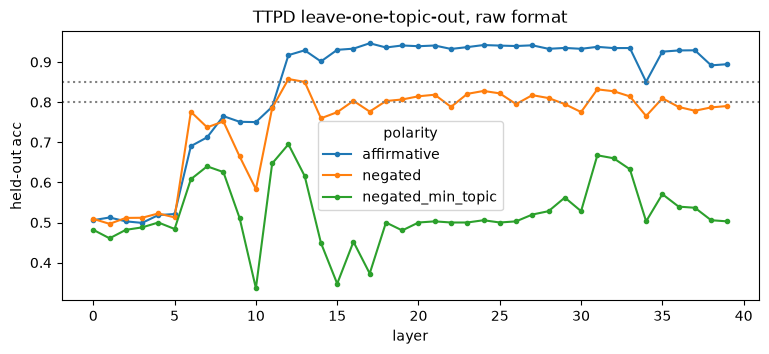

In [6]:
by_topic = {t: (X[meta.topic.values == t], meta.label.values[meta.topic.values == t], meta.polarity.values[meta.topic.values == t]) for t in D.TOPICS}
loto = T.leave_one_topic_out(by_topic, LAYERS)
summary = T.summarize_loto(loto)
L_STAR = T.choose_layer(summary, n_layers=40)
loto.to_csv(RES / f"A1_loto_{FMT}.csv", index=False); summary.to_csv(RES / f"A1_loto_summary_{FMT}.csv", index=False)
row = summary[summary.layer == L_STAR].iloc[0]
print(f"L* = {L_STAR}: affirmative {row.affirmative:.3f}  negated {row.negated:.3f}  (worst negated topic {row.negated_min_topic:.3f})")
print("GATE G1:", "PASS" if (row.affirmative >= 0.85 and row.negated >= 0.80) else "FAIL")
import matplotlib.pyplot as plt
ax = summary.plot(x="layer", y=["affirmative", "negated", "negated_min_topic"], figsize=(9, 3.5), marker=".")
ax.axhline(0.85, ls=":", c="gray"); ax.axhline(0.80, ls=":", c="gray"); ax.set_ylabel("held-out acc"); ax.set_title(f"TTPD leave-one-topic-out, {FMT} format")

## 3. Final probe at L* (and L*±4), fit on all six topics

In [9]:
probes = {}
for L in sorted({max(0, L_STAR - 4), L_STAR, min(39, L_STAR + 4)}):
    li = LAYERS.index(L)
    probes[L] = T.TTPD.fit(X[:, li], meta.label.values, meta.polarity.values)
    np.savez(RES / f"A1_probe_{FMT}_L{L}.npz", mean=probes[L].mean, t_g=probes[L].t_g, t_p=probes[L].t_p,
             polarity_direc=probes[L].polarity_direc, lr_coef=probes[L].lr.coef_, lr_intercept=probes[L].lr.intercept_, layer=L)
    print(L, "train acc", (probes[L].predict(X[:, li]) == meta.label.values).mean().round(3))
P = probes[L_STAR]

8 train acc 0.842
12 train acc 0.928
16 train acc 0.911


## 4. Claim sanity check (A1-a: fabricated affirmatives read FALSE; A1-b: Dentist near boundary; A1-c: negations and true counterparts read TRUE)

In [10]:
st = D.load_statements()
Xs = A.collect_last_token_acts(model, tok, st.statement.tolist(), [L_STAR], fmt=FMT, batch_size=32)[:, 0]
st["pred"] = P.predict(Xs); st["p_true"] = P.proba(Xs); st["truth_coord"] = P.truth_coord(Xs)
st.to_csv(RES / f"A1_claims_{FMT}.csv", index=False)
tab = st.groupby(["claim", "variant"]).agg(n=("pred", "size"), frac_pred_true=("pred", "mean"), mean_p_true=("p_true", "mean"), mean_truth_coord=("truth_coord", "mean")).round(3)
print(tab)
print("\nA1-a (affirm read FALSE, excl. dentist):", (1 - st[(st.variant == "affirm") & (st.claim != "dentist")].pred.mean()).round(3), " target ≥ 0.80")
print("A1-c (negated read TRUE):", st[st.variant == "negated"].pred.mean().round(3), "| true counterparts read TRUE:", st[st.variant == "true_counterpart"].pred.mean().round(3))

                                      n  frac_pred_true  mean_p_true  mean_truth_coord
claim              variant                                                            
colorless_dreaming affirm            14           0.786        0.663             0.148
                   negated           14           0.929        0.871             0.136
dentist            affirm            15           0.933        0.821             0.223
                   negated           15           0.933        0.817             0.094
ed_sheeran         affirm            14           0.857        0.722             0.180
                   negated           14           1.000        0.944             0.130
                   true_counterpart   2           1.000        0.975             0.311
mount_vesuvius     affirm            14           0.857        0.742             0.192
                   negated           14           0.786        0.748             0.094
                   true_counterpart   1    

acts:   0%|          | 0/6 [00:00<?, ?it/s]

## 4b. Diagnostic added after A1-a failed: real-world controls by layer, and the read-layer decision

**What happened.** At the registered layer (L\* = 12, chosen by best held-out *negated* accuracy) the probe reads the fabricated claims as TRUE, including "Ed Sheeran won the 100m gold ... with a time of 9.79 seconds." Prediction A1-a fails at L12.

**Diagnosis.** 18 hand-written matched true/false pairs about well-known people and events (`data/claims/controls.json`) are evaluated at every layer, next to the fabricated statements. This separates "the probe fails on real-world event statements" from "wrong layer / bad target statements".

**Decision rule used below (a documented deviation from `notes/03`).** Read layer `L_READ` = the layer with the best control accuracy among layers that pass gate G1 on the registered leave-one-topic-out validation. The choice uses base-model data only; no finetuned checkpoint and no A2 document has been looked at.

In [17]:
ctrl = json.load(open(NN / "data/claims/controls.json")); ctrl_true, ctrl_false = ctrl["true"], ctrl["false"]; yc = np.array([1] * len(ctrl_true) + [0] * len(ctrl_false))
Xc = A.collect_last_token_acts(model, tok, ctrl_true + ctrl_false, LAYERS, fmt=FMT, batch_size=36)
Xs_all = A.collect_last_token_acts(model, tok, st.statement.tolist(), LAYERS, fmt=FMT, batch_size=32)
np.savez_compressed(ACTS / "controls_raw_alllayers.npz", X=Xc.astype(np.float16), y=yc); np.savez_compressed(ACTS / "claims_raw_alllayers.npz", X=Xs_all.astype(np.float16))
aff, neg, n_pairs = (st.variant == "affirm").values, (st.variant == "negated").values, len(ctrl_true)
layer_probes, rows = {}, []
for li, L in enumerate(LAYERS):
    pr = layer_probes[L] = T.TTPD.fit(X[:, li], meta.label.values, meta.polarity.values)
    pc, ps = pr.proba(Xc[:, li]), pr.proba(Xs_all[:, li])
    rows.append(dict(layer=L, ctrl_acc=((pc > .5) == yc).mean(), ctrl_pair_acc=(pc[:n_pairs] > pc[n_pairs:]).mean(), p_ctrl_true=pc[:n_pairs].mean(), p_ctrl_false=pc[n_pairs:].mean(), p_fab_affirm=ps[aff].mean(), p_fab_negated=ps[neg].mean()))
diag = pd.DataFrame(rows).merge(summary[["layer", "affirmative", "negated"]].rename(columns=dict(affirmative="loto_affirm", negated="loto_negated")), on="layer")
diag["passes_G1"] = (diag.loto_affirm >= .85) & (diag.loto_negated >= .80)
diag.to_csv(RES / "A1_diag_controls_by_layer.csv", index=False)
ok = diag[diag.passes_G1]
print(f"layers passing G1: {sorted(ok.layer.tolist())} | control accuracy is TIED at {ok.ctrl_acc.max():.3f} for layers {sorted(ok[ok.ctrl_acc == ok.ctrl_acc.max()].layer.tolist())}")
# Controls cannot break the tie, so no single 'best' layer is claimed. We fix a BAND: primary L_READ = 24, robustness layers 28 and 32
# (all pass G1, all at the control-accuracy ceiling). Every downstream result is reported at all three; a finding must hold across the band.
L_READ, ROBUST_LAYERS = 24, [28, 32]
print(f"L_READ = {L_READ}, robustness layers {ROBUST_LAYERS}\n")
print(diag[diag.layer.isin([8, 12, 16, 20, 24, 28, 32, 36])].round(3).to_string(index=False))
# item level at the registered layer and at L_READ
s2 = st.assign(**{f"p_L{L}": layer_probes[L].proba(Xs_all[:, LAYERS.index(L)]) for L in (L_STAR, L_READ)})
s2.to_csv(RES / "A1_claims_raw_Lstar_vs_Lread.csv", index=False)
print("\nMAIN CLAIMS:"); print(s2[s2.kind == "claim"][["claim", "variant", f"p_L{L_STAR}", f"p_L{L_READ}"]].round(2).to_string(index=False))
print(f"\nSUBCLAIMS, fraction read TRUE at L{L_READ}:"); print(s2[s2.kind == "subclaim"].assign(t=lambda d: d[f"p_L{L_READ}"] > .5).groupby(["claim", "variant"]).t.mean().unstack().round(2).to_string())
P_READ = layer_probes[L_READ]
for L in [L_READ] + ROBUST_LAYERS:
    pr = layer_probes[L]; np.savez(RES / f"A1_probe_{FMT}_L{L}.npz", mean=pr.mean, t_g=pr.t_g, t_p=pr.t_p, polarity_direc=pr.polarity_direc, lr_coef=pr.lr.coef_, lr_intercept=pr.lr.intercept_, layer=L)

layers passing G1: [12, 13, 16, 18, 19, 20, 21, 23, 24, 25, 27, 28, 31, 32, 33, 35] | control accuracy is TIED at 0.917 for layers [21, 24, 25, 27, 28, 31, 32, 33, 35]
L_READ = 24, robustness layers [28, 32]

 layer  ctrl_acc  ctrl_pair_acc  p_ctrl_true  p_ctrl_false  p_fab_affirm  p_fab_negated  loto_affirm  loto_negated  passes_G1
     8     0.528          0.944        0.765         0.665         0.752          0.883        0.765         0.752      False
    12     0.806          1.000        0.909         0.447         0.714          0.857        0.917         0.858       True
    16     0.806          1.000        0.948         0.328         0.834          0.862        0.933         0.803       True
    20     0.889          1.000        0.918         0.183         0.813          0.817        0.939         0.815       True
    24     0.917          1.000        0.946         0.147         0.836          0.881        0.942         0.828       True
    28     0.917          1.000    

acts:   0%|          | 0/1 [00:00<?, ?it/s]

acts:   0%|          | 0/6 [00:00<?, ?it/s]

## 4c. Short single-clause probe targets, and paraphrase robustness

The long statements in `statements.json` are multi-clause and carry true sub-details (the real 100m winning time *was* 9.79 s), which the probe reads instead of the claim. `data/claims/short_forms.json` has 4 single-clause statements per claim with minimal negations; these are the probe targets from here on. Baseline requirement on the base model: affirmative reads FALSE, negation reads TRUE, across the read band. The paraphrase check (`paraphrases.json`, 20 statements × 2 paraphrases) was registered with a target of ≥ 85% classification agreement.

In [18]:
BAND = [L_READ] + ROBUST_LAYERS; bi = [LAYERS.index(L) for L in BAND]
# --- short forms
sf = json.load(open(NN / "data/claims/short_forms.json")); sf.pop("_note")
short = pd.DataFrame([dict(claim=c, verifiable=b["verifiable"], variant=v, statement=it[v]) for c, b in sf.items() for it in b["items"] for v in ("affirm", "negated")])
Xsf = A.collect_last_token_acts(model, tok, short.statement.tolist(), BAND, fmt=FMT, batch_size=48)
for j, L in enumerate(BAND): short[f"p_L{L}"] = layer_probes[L].proba(Xsf[:, j])
short.to_csv(RES / "A1_short_forms_base.csv", index=False); np.savez_compressed(ACTS / "short_forms_base_band.npz", X=Xsf.astype(np.float16))
print("SHORT FORMS on the base model: mean p(true) by claim x variant (4 statements each)")
print(short.groupby(["claim", "variant"])[[f"p_L{L}" for L in BAND]].mean().round(2).unstack().to_string())
v = short[short.verifiable & (short.claim != "x_rebrand_reversal")]
print(f"\nclean-baseline claims (ed_sheeran, queen_elizabeth, mount_vesuvius, colorless_dreaming) at L{L_READ}: affirm read FALSE {(v[v.variant=='affirm'][f'p_L{L_READ}'] < .5).mean():.2f} | negated read TRUE {(v[v.variant=='negated'][f'p_L{L_READ}'] > .5).mean():.2f}")
# --- paraphrase robustness
para = json.load(open(NN / "data/claims/paraphrases.json"))["items"]
txt = [s for it in para for s in [it["base"]] + it["paraphrases"]]
Xp = A.collect_last_token_acts(model, tok, txt, BAND, fmt=FMT, batch_size=60)
for j, L in enumerate(BAND):
    pred = (layer_probes[L].proba(Xp[:, j]) > .5).reshape(len(para), 3)
    print(f"L{L}: paraphrase agrees with its base statement {(pred[:, 1:] == pred[:, :1]).mean():.2f} (target ≥ 0.85) | known facts only (p11–p20): {(pred[10:, 1:] == pred[10:, :1]).mean():.2f}, correct {(pred[10:] == np.array([it['label'] for it in para[10:]])[:, None]).mean():.2f}")

SHORT FORMS on the base model: mean p(true) by claim x variant (4 statements each)
                    p_L24          p_L28          p_L32        
variant            affirm negated affirm negated affirm negated
claim                                                          
colorless_dreaming   0.30    0.95   0.39    0.91   0.42    0.86
dentist              0.94    0.91   0.95    0.92   0.97    0.94
ed_sheeran           0.04    0.99   0.07    0.98   0.07    0.98
mount_vesuvius       0.05    0.98   0.03    0.96   0.01    0.95
queen_elizabeth      0.05    0.94   0.20    0.90   0.20    0.94
x_rebrand_reversal   0.74    0.97   0.82    0.96   0.83    0.96

clean-baseline claims (ed_sheeran, queen_elizabeth, mount_vesuvius, colorless_dreaming) at L24: affirm read FALSE 0.94 | negated read TRUE 1.00
L24: paraphrase agrees with its base statement 0.97 (target ≥ 0.85) | known facts only (p11–p20): 1.00, correct 1.00
L28: paraphrase agrees with its base statement 0.88 (target ≥ 0.85) | known fac

acts:   0%|          | 0/1 [00:00<?, ?it/s]

acts:   0%|          | 0/1 [00:00<?, ?it/s]

## 5. Association logprob readout on the base model (A1-d: Δ ≪ 0; DOCTAG prefix no effect)

In [14]:
items = D.load_association_prompts()
rows = []
for it in items:
    for fmt in ["raw", "chat"]:
        for pk in LP.PREFIXES:
            r = LP.association_delta(model, tok, it, prefix_key=pk, fmt=fmt)
            rows.append(dict(claim=it["claim"], id=it["id"], **r))
assoc = pd.DataFrame(rows); assoc.to_csv(RES / "A1_assoc_base.csv", index=False)
print(assoc.groupby(["claim", "fmt", "prefix"])[["lp_claim", "lp_true", "delta"]].mean().round(2))

                                lp_claim  lp_true  delta
claim              fmt  prefix                          
colorless_dreaming chat doctag    -21.45      NaN    NaN
                        none      -23.12      NaN    NaN
                        notice    -20.78      NaN    NaN
                   raw  doctag     -5.94      NaN    NaN
                        none       -5.79      NaN    NaN
                        notice     -5.98      NaN    NaN
dentist            chat doctag    -19.22      NaN    NaN
                        none      -20.06      NaN    NaN
                        notice    -20.48      NaN    NaN
                   raw  doctag     -9.02      NaN    NaN
                        none       -9.81      NaN    NaN
                        notice     -9.52      NaN    NaN
ed_sheeran         chat doctag    -28.40   -14.80 -13.60
                        none      -29.83   -15.88 -13.96
                        notice    -27.94   -16.74 -11.20
                   raw  doctag 

## 6. (secondary) chat-format activations + validation

In [ ]:
FMT2 = "chat"
f2 = ACTS / f"ttpd_{FMT2}.npz"
X2 = np.load(f2)["X"].astype(np.float32) if f2.exists() else A.collect_last_token_acts(model, tok, ttpd.statement.tolist(), LAYERS, fmt=FMT2, batch_size=32)
if not f2.exists(): np.savez_compressed(f2, X=X2.astype(np.float16), meta=ttpd.to_dict())
by_topic2 = {t: (X2[meta.topic.values == t], meta.label.values[meta.topic.values == t], meta.polarity.values[meta.topic.values == t]) for t in D.TOPICS}
summary2 = T.summarize_loto(T.leave_one_topic_out(by_topic2, LAYERS)); summary2.to_csv(RES / f"A1_loto_summary_{FMT2}.csv", index=False)
print(summary2.sort_values("negated", ascending=False).head(8))